# Employee Turnover Analytics

## Project Statement:
Portobello Tech is an app innovator that has devised an intelligent way of predicting employee turnover within the company. It periodically evaluates employees' work details including the number of projects they worked upon, average monthly working hours, time spent in the company, promotions in the last 5 years, and salary level.
Data from prior evaluations show the employee’s satisfaction at the workplace. The data could be used to identify patterns in work style and their interest to continue to work in the company. 
The HR Department owns the data and uses it to predict employee turnover. Employee turnover refers to the total number of workers who leave a company over a certain time period.

|Column Name|Description| 
|-----------|-----------|
|satisfaction_level|satisfaction level at the job of an employee| 
|last_evaluation| Rating between 0 to 1, received by an employee at his last evaluation|
| number_project|Number of projects, an employee involved in|
| average_montly_hours|Average number of hours in a month, spent by an employee at office|
|time_spend_company |Number of years spent in the company |    
|Work_accident |0 - no accident during employee stay, 1 - accident during employee stay |           
|left|"0 indicates employee stays in the company, 1 indicates - employee left the company" |
|promotion_last_5years|Number of promotions in his stay|
|Department|Department, an employee belongs to |
|salary | Salary in USD |           
	                  

In [1]:
# import pandas libray for performing operation(reading, visulization, modifiying) on data
import pandas as pd

In [4]:
#reading xlsx file
df = pd.read_excel("../data/data.xlsx")

## 1. Data Wrangling - Perform data quality check and fix

In [3]:
# printing first 5 records from the top
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [4]:
# printing last 5 records from the last
df.tail()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low
14998,0.37,0.52,2,158,3,0,1,0,support,low


In [5]:
# columns types and total records
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


In [6]:
# reading statistical values - min, max, mean, std etc: 
df.describe().T

,count,mean,std,min,25%,50%,75%,max
satisfaction_level,14999.0,0.612834,0.248631,0.09,0.44,0.64,0.82,1.0
last_evaluation,14999.0,0.716102,0.171169,0.36,0.56,0.72,0.87,1.0
number_project,14999.0,3.803054,1.232592,2.00,3.00,4.00,5.00,7.0
average_montly_hours,14999.0,201.050337,49.943099,96.00,156.00,200.00,245.00,310.0
time_spend_company,14999.0,3.498233,1.460136,2.00,3.00,3.00,4.00,10.0
Work_accident,14999.0,0.144610,0.351719,0.00,0.00,0.00,0.00,1.0
left,14999.0,0.238083,0.425924,0.00,0.00,0.00,0.00,1.0
promotion_last_5years,14999.0,0.021268,0.144281,0.00,0.00,0.00,0.00,1.0


In [7]:
# printing columns: 
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'sales', 'salary'],
      dtype='str')

In [8]:
# checking for unique values in every column: 
for col in df.columns:
    print(f"{ col } - {df[col].unique()} \n")


satisfaction_level - [0.38 0.8  0.11 0.72 0.37 0.41 0.1  0.92 0.89 0.42 0.45 0.84 0.36 0.78
 0.76 0.09 0.46 0.4  0.82 0.87 0.57 0.43 0.13 0.44 0.39 0.85 0.81 0.9
 0.74 0.79 0.17 0.24 0.91 0.71 0.86 0.14 0.75 0.7  0.31 0.73 0.83 0.32
 0.54 0.27 0.77 0.88 0.48 0.19 0.6  0.12 0.61 0.33 0.56 0.47 0.28 0.55
 0.53 0.59 0.66 0.25 0.34 0.58 0.51 0.35 0.64 0.5  0.23 0.15 0.49 0.3
 0.63 0.21 0.62 0.29 0.2  0.16 0.65 0.68 0.67 0.22 0.26 0.99 0.98 1.
 0.52 0.93 0.97 0.69 0.94 0.96 0.18 0.95] 

last_evaluation - [0.53 0.86 0.88 0.87 0.52 0.5  0.77 0.85 1.   0.54 0.81 0.92 0.55 0.56
 0.47 0.99 0.51 0.89 0.83 0.95 0.57 0.49 0.46 0.62 0.94 0.48 0.8  0.74
 0.7  0.78 0.91 0.93 0.98 0.97 0.79 0.59 0.84 0.45 0.96 0.68 0.82 0.9
 0.71 0.6  0.65 0.58 0.72 0.67 0.75 0.73 0.63 0.61 0.76 0.66 0.69 0.37
 0.64 0.39 0.41 0.43 0.44 0.36 0.38 0.4  0.42] 

number_project - [2 5 7 6 4 3] 

average_montly_hours - [157 262 272 223 159 153 247 259 224 142 135 305 234 148 137 143 160 255
 282 147 304 139 158 242 239 128 1

In [9]:
# checking for null or missing value in data frame
df.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

In [10]:
print("-------------------------------------------")
print(f'Total rows          : {len(df)}')
print(f'Duplicate rows      : {df.duplicated().sum()}')
print(f'Unique rows         : {len(df) - df.duplicated().sum()}')
print("-------------------------------------------")

df.drop_duplicates(inplace=True)
df

-------------------------------------------
Total rows          : 14999
Duplicate rows      : 3008
Unique rows         : 11991
-------------------------------------------


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
11995,0.90,0.55,3,259,10,1,0,1,management,high
11996,0.74,0.95,5,266,10,0,0,1,management,high
11997,0.85,0.54,3,185,10,0,0,1,management,high
11998,0.33,0.65,3,172,10,0,0,1,marketing,high


In [11]:
df.left.value_counts()*100/df.left.count()

left
0    83.39588
1    16.60412
Name: count, dtype: float64

In [12]:
df.shape

(11991, 10)

### Observations - 
- 8 number columns : float64(2), int64(6), 
- 2 string columns: salary(ordinal category) and sales(nominal category).
- left, Work_accident and promotion_last_5years contain only 0 and 1.
- No missing value found.
- There are 3008 duplicate values present in the dataframe. 
- Target column - left, does not have balanced data, 83% record contain 0, and 16.6% record contains 1.

|column|range|
|------|-----|
|satisfaction_level| 0-1|
|last_evaluation|0-1|
| number_project|2-7|
| average_montly_hours|96-310|
|time_spend_company |2-10|    
|Work_accident |0,1|
|left|0,1|
|promotion_last_5years|0,1|
|Department|'sales','accounting', 'hr','technical','support', 'management','IT', 'product_mng', 'marketing', 'RandD'|
|salary |low,mid,high|

## 2. Understand what factors contributed most to employee turnover by EDA

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

### 2.1. Heatmap of the Correlation Matrix between all numerical features/columns in the data.

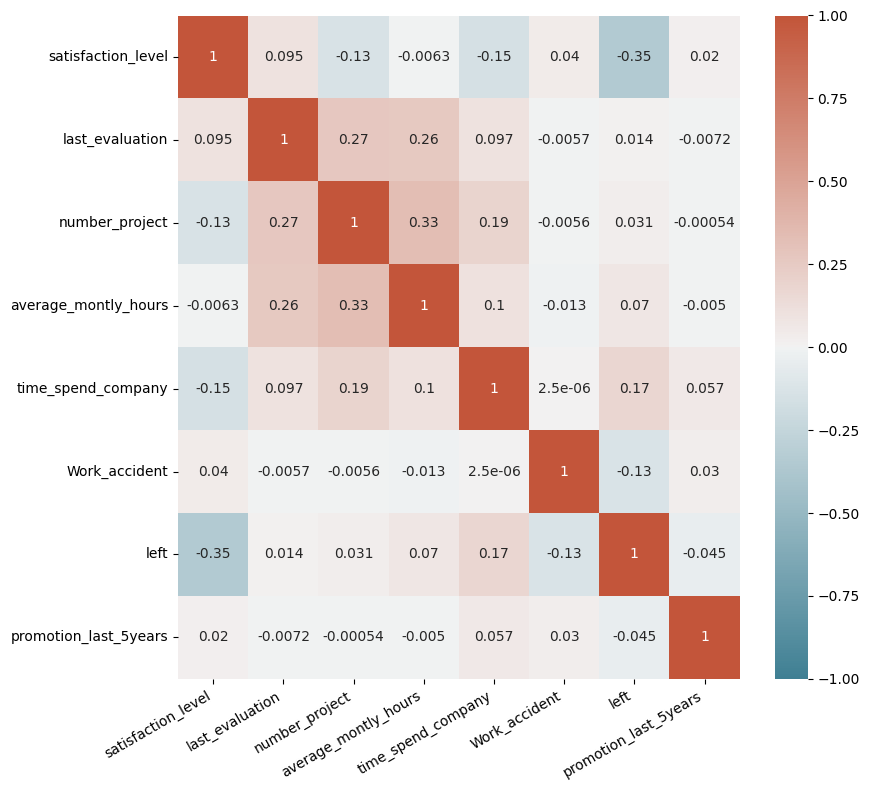

In [14]:
plt.figure(figsize=(9,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, cmap=sns.diverging_palette(220, 20, as_cmap=True))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

#### Observastion
- satisfaction_level is highly negativly correlated with dependent column(left) = -0.35 
- time-spend_company is posively correlated with dependent column(left) = 0.17
- number_project is positively correlated with average_monthly_hours, time_spend_company,last_evaluation
- last_evaluation is positively correlated with last_evaluation

### 2.2. Draw the distribution plot of 

#### 2.2.1. Employee Satisfaction (use column satisfaction_level)

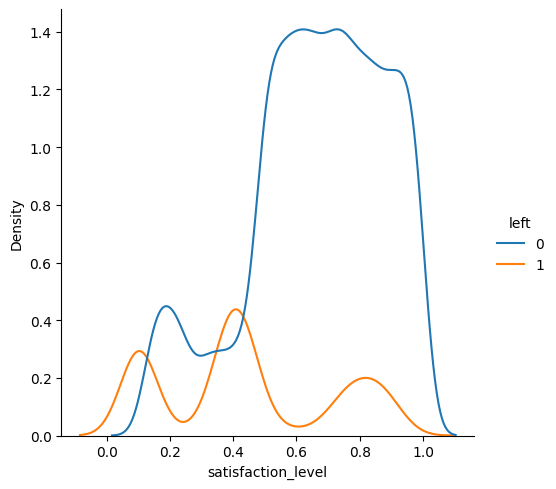

In [15]:
sns.displot(data=df, x="satisfaction_level", kind="kde", hue="left")

#### 2.2.2. Employee Evaluation (use column last_evaluation)

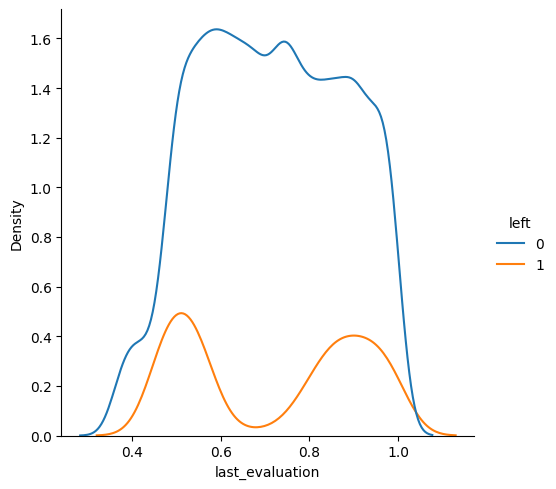

In [16]:
sns.displot(data=df, x="last_evaluation", kind="kde", hue="left")

#### 2.2.3. Employee Average Monthly Hours (use column average_montly_hours)

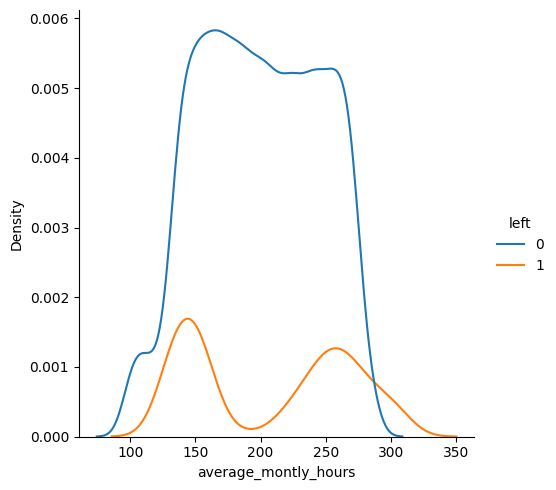

In [17]:
sns.displot(data=df, x="average_montly_hours", kind="kde", hue="left")
 

#### Observastion
From the above chart we have observe there are three category of employees: 
1. The High-Performer - "Burnout"
    - Exceptionally high evaluation scores, peaking between 0.8 and 1.0.
    - Heavily overworked, often exceeding 250 to 300 average monthly hours.
    - This group shows a distinct peak in the satisfaction graph around the 0.8 mark. This suggests they may actually enjoy their work but are likely leaving due to unsustainable pressure or better external offers.
2. The Disengaged "At-Risk"
    - This group receives lower evaluation scores, specifically in the 0.4 to 0.5 range.
    - Their monthly hours are significantly lower than average, peaking between 125 and 150 hours.
    - These individuals are likely under-utilized, struggling in their roles, or have already "checked out" mentally before physically leaving.
3. Comfortable "safe-zone".
   - Employees with satisfaction levels between 0.5 and 0.9 are the most likely to stay.
   - Moderate evaluation between the range of 0.6 to 0.8.
   - Moderate working hours(175-225) which is perfect average monthly hours for a employee.

### 2.3. Bar plot of Employee Project Count of both employees who left and who stayed in the organization 

<Axes: ylabel='number_project'>

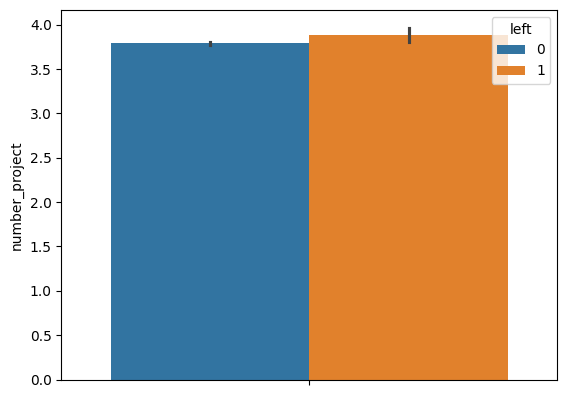

In [18]:
sns.barplot(data=df, y="number_project", hue="left")

#### Observations - 
- Employees who left the organization tended to handle a slightly higher average number of projects compared to those who stayed.
- the average project count is very consistent across both groups of employees.

## 3. Perform clustering of Employees who left based on their satisfaction and evaluation.

In [19]:
from sklearn.cluster import KMeans
import numpy as np

### 3.1. Choose columns satisfaction_level, last_evaluation and left.


In [20]:
df_left = df[df['left'] == 1]
left_emp_data = df_left[["satisfaction_level", "last_evaluation"]]

### 3.2. Do KMeans clustering of employees who left the company into 3 clusters.


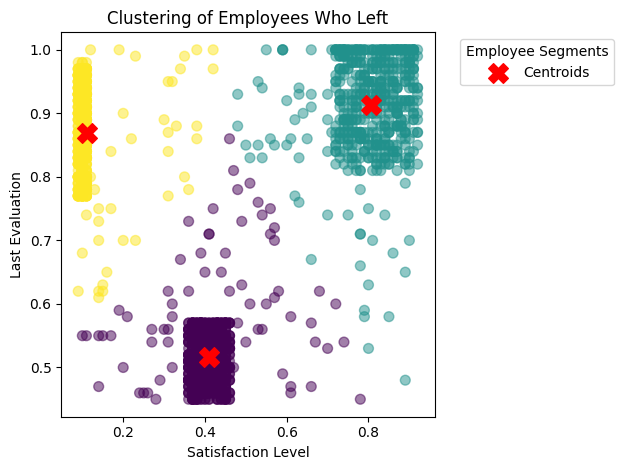

In [21]:

kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=500, random_state=42)
df_left['clusters'] = kmeans.fit_predict(left_emp_data)

centers = kmeans.cluster_centers_
plt.scatter(left_emp_data.iloc[:, 0], left_emp_data.iloc[:, 1], c=df_left['clusters'], s=50, cmap='viridis', alpha=0.5)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centroids')

plt.title('Clustering of Employees Who Left')
plt.xlabel('Satisfaction Level')
plt.ylabel('Last Evaluation')
plt.legend(title="Employee Segments", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 3.3. Based on the satisfaction and evaluation factors, give your thoughts on the employee clusters.

In [22]:
df_left['clusters'].value_counts().sort_index()
df_left.info()

<class 'pandas.DataFrame'>
Index: 1991 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     1991 non-null   float64
 1   last_evaluation        1991 non-null   float64
 2   number_project         1991 non-null   int64  
 3   average_montly_hours   1991 non-null   int64  
 4   time_spend_company     1991 non-null   int64  
 5   Work_accident          1991 non-null   int64  
 6   left                   1991 non-null   int64  
 7   promotion_last_5years  1991 non-null   int64  
 8   sales                  1991 non-null   str    
 9   salary                 1991 non-null   str    
 10  clusters               1991 non-null   int32  
dtypes: float64(2), int32(1), int64(6), str(2)
memory usage: 178.9 KB


In [23]:
cluster_summary = df_left.groupby('clusters')[['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years' ]].mean()

cluster_summary

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
clusters,,,,,,,,
0,0.410133,0.517195,2.172949,149.640798,3.065410,0.053215,1.0,0.005543
1,0.805874,0.912577,4.511712,242.003604,5.012613,0.052252,1.0,0.003604
2,0.111199,0.869064,6.119850,271.840824,4.084270,0.052434,1.0,0.001873


##### Cluster 0 = Medium satisfaction, Low evaluation, low average monthly hours
- These employees were neither happy nor performing well
- Likely left because they felt stuck with no growth or recognition
- Action: Better performance management and career development programs

##### Cluster 1  = High satisfaction, very high evaluation
- These employees were happy AND performing well, but still left
- Likely got a better opportunity elsewhere - competitor poaching or better offer
- Action: Stay interviews, career growth paths, competitive compensation benchmarking

##### cluster 2 = Very low satisfaction, high evaluation, high no. of projects, less promoted, high average monthly hours
- outperformer, talented employees who left
- Likely overworked, underpaid or underappreciated despite delivering results

## 4. Handle the left Class Imbalance using SMOTE technique.

### 4.1. Pre-Process the data by converting categorical columns to numerical columns by

In [24]:
salary_dummies = pd.get_dummies(df['salary'],dtype=int, drop_first=True)
sales_dummies = pd.get_dummies(df['sales'],dtype=int, drop_first=True)
df = pd.concat([df, salary_dummies], axis=1)
df = pd.concat([df, sales_dummies], axis=1)

In [25]:
df.drop(columns=['sales', 'salary'], inplace=True)

In [26]:
df.info()

<class 'pandas.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11991 non-null  float64
 1   last_evaluation        11991 non-null  float64
 2   number_project         11991 non-null  int64  
 3   average_montly_hours   11991 non-null  int64  
 4   time_spend_company     11991 non-null  int64  
 5   Work_accident          11991 non-null  int64  
 6   left                   11991 non-null  int64  
 7   promotion_last_5years  11991 non-null  int64  
 8   low                    11991 non-null  int64  
 9   medium                 11991 non-null  int64  
 10  RandD                  11991 non-null  int64  
 11  accounting             11991 non-null  int64  
 12  hr                     11991 non-null  int64  
 13  management             11991 non-null  int64  
 14  marketing              11991 non-null  int64  
 15  product_mng       

### 4.2. Do the stratified split of the dataset to train and test in the ratio 80:20 with random_state=123.


In [27]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
X = df
Y = df.left
X.drop(columns="left",inplace=True)

In [28]:
x_train,x_test,y_train,y_test= train_test_split(X,Y,test_size=.20, random_state=123, stratify=Y)

print("---------------------------------------")
print(f"train size - {x_train.shape[0]}")
print(f"test size - {x_test.shape[0]}")
print(f"target train size - {y_train.shape[0]}")
print(f"traget test size - {y_test.shape[0]}")
print("---------------------------------------")

---------------------------------------
train size - 9592
test size - 2399
target train size - 9592
traget test size - 2399
---------------------------------------


### 4.3. Upsample the train dataset using SMOTE technique from the imblearn module.

In [29]:
smote = SMOTE(random_state=123)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

print("---------------------------------------")
print('Before SMOTE:')
print('\n Class distribution before SMOTE:')
print(y_train.value_counts())
print(f'X_train shape before SMOTE: { x_train.shape}')
print(f'X_train shape after SMOTE : {x_train_smote.shape}')
print('\n Class distribution after SMOTE:')
print(pd.Series(y_train_smote).value_counts())
print("---------------------------------------")

---------------------------------------
Before SMOTE:

 Class distribution before SMOTE:
left
0    7999
1    1593
Name: count, dtype: int64
X_train shape before SMOTE: (9592, 17)
X_train shape after SMOTE : (15998, 17)

 Class distribution after SMOTE:
left
0    7999
1    7999
Name: count, dtype: int64
---------------------------------------


## 5. Perform 5-Fold cross-validation model training and evaluate performance. 


In [30]:
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report

# 5-fold 
kf = KFold(n_splits=5, shuffle=True, random_state=123)

# common method to plot a classification report for each model
def plot_classification_report(y_true, y_pred, model_name):
    # Generate the report as a dictionary
    report = classification_report(y_true, y_pred, output_dict=True)
    
    # Convert to DataFrame and remove unnecessary rows
    report_df = pd.DataFrame(report).iloc[:-1, :].T 
    
    # Create the heatmap
    plt.figure(figsize=(4, 4))
    sns.heatmap(report_df, annot=True, cmap="Blues", fmt='.2f', cbar=True)
    plt.title(f'Classification Report: {model_name}')
    plt.xlabel('Metrics')
    plt.ylabel('Classes')
    plt.show()

### 5.1 Train a Logistic Regression model and apply a 5-Fold CV and plot the classification report.


---------------------------------------------
Logistic Regression Model Accuracy: 83.38
---------------------------------------------


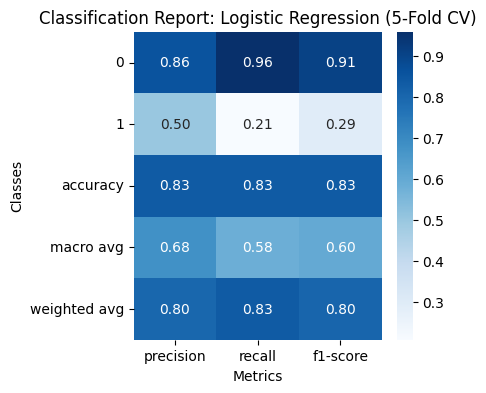

In [31]:
# Model : Logistic Regressions
lr_model = LogisticRegression(max_iter=10000, random_state=123)
y_train_pred = cross_val_predict(lr_model, x_train, y_train, cv=kf)
scores = cross_val_score(lr_model, x_train, y_train, cv=kf)

print("---------------------------------------------")
print(f"Logistic Regression Model Accuracy: {np.mean(scores)*100:.2f}")
print("---------------------------------------------")

# ploting the model classfication heatmap 
plot_classification_report(y_train, y_train_pred, "Logistic Regression (5-Fold CV)")


### 5.2. Train a Random Forest Classifier model and apply the 5-Fold CV and plot the classification report.

---------------------------------------------
RandomForest Model Accuracy: 98.39
---------------------------------------------


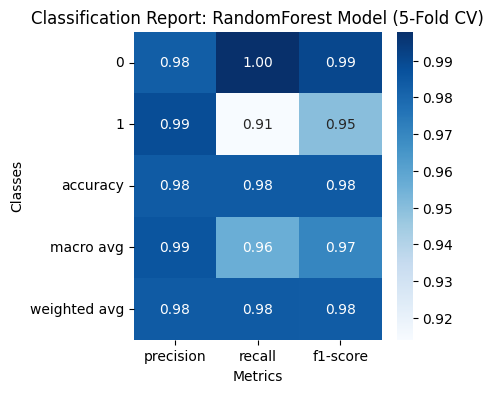

In [32]:
# Model : Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=123)
rf_y_train_pred = cross_val_predict(rf_model, x_train, y_train, cv=kf)
rf_scores = cross_val_score(rf_model, x_train, y_train, cv=kf)

print("---------------------------------------------")
print(f"RandomForest Model Accuracy: {np.mean(rf_scores)*100:.2f}")
print("---------------------------------------------")

# ploting the model classfication heatmap 
plot_classification_report(y_train, rf_y_train_pred, "RandomForest Model (5-Fold CV)")

### 5.3. Train a  Gradient Boosting Classifier model and apply the 5-Fold CV and plot the classification report.

---------------------------------------------
GradientBoosting Model Accuracy: 98.07
---------------------------------------------


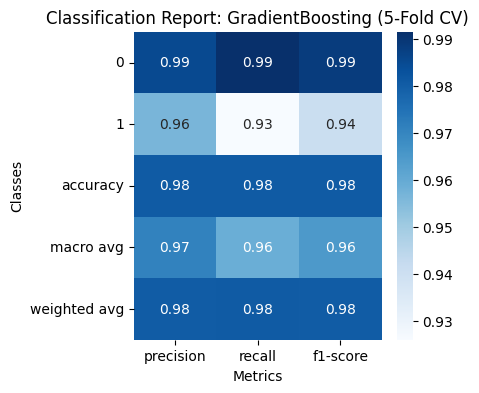

In [33]:
# Model : Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(random_state=123)
gb_y_train_pred = cross_val_predict(gb_model, x_train, y_train, cv=kf)
gb_scores = cross_val_score(gb_model, x_train, y_train, cv=kf)
print("---------------------------------------------")
print(f"GradientBoosting Model Accuracy: {np.mean(gb_scores)*100:.2f}")
print("---------------------------------------------")
# ploting the model classfication heatmap
plot_classification_report(y_train, gb_y_train_pred, "GradientBoosting (5-Fold CV)")

## 6. Identify the best model and justify the evaluation metrics used

### 6.1. Find the confusion matrix for each of the models.

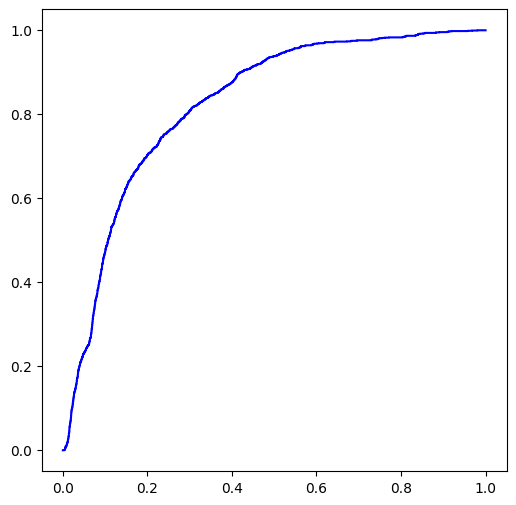

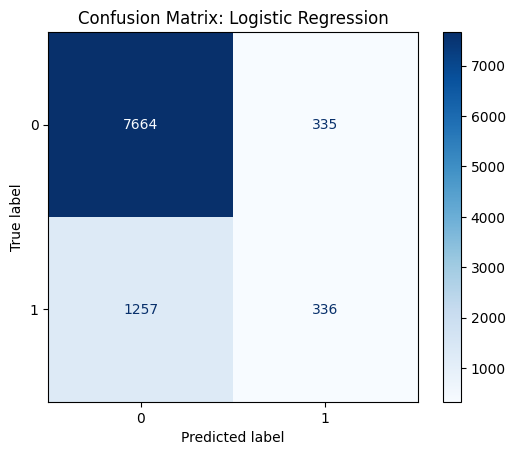

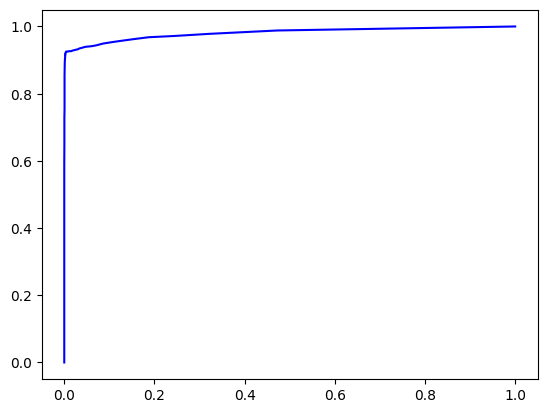

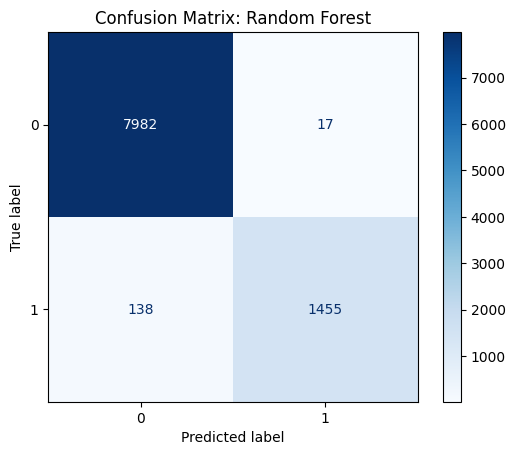

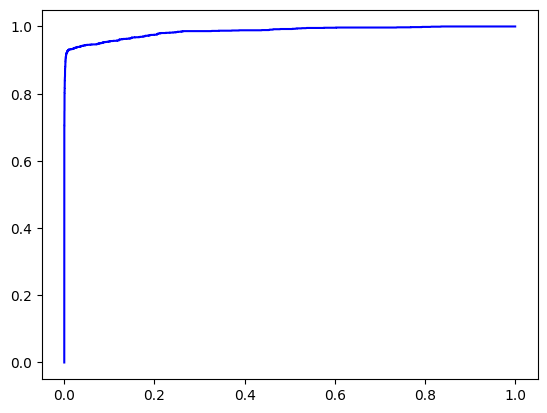

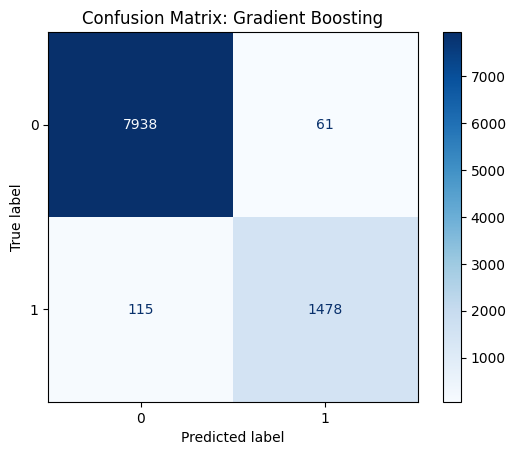

In [46]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

plt.figure(figsize=(6, 6))

for name, model in models.items():
    # 1. Get probabilities for ROC
    y_probs = cross_val_predict(model, x_train, y_train, cv=5, method='predict_proba')[:, 1]
    fpr, tpr, _ = roc_curve(y_train, y_probs)
    roc_auc = auc(fpr, tpr)
    
    # 2. Plot ROC Curve
    plt.plot(fpr, tpr, color='b', label=f'{name} (AUC = {roc_auc:.2f})')
 
    # 3. Plot Confusion Matrix
    y_pred = cross_val_predict(model, x_train, y_train, cv=5)
    cm = confusion_matrix(y_train, y_pred)
    cm_display = ConfusionMatrixDisplay(confusion_matrix=cm)
    cm_display.plot(cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.show()



#### Observations:
- Logistic Regression Model Accuracy: 83.38
- RandomForest Model Accuracy: 98.39
- GradientBoosting Model Accuracy: 98.07

#### Conclusion: 
- Best model for this problem Gradient Boosting Model, as the recall is very high  compared to other, while RandomForest Model  has a high precision but

### 6.2. From the confusion matrix, explain which metric needs to be used- Recall or Precision?

#### The Correct Predictions
- True Negatives (7938): The model correctly predicted that 7938 employees would stay. These people are satisfied and the model got it right.
- True Positives (1478): The model correctly identified 1478 employees who actually left. This is the group HR can potentially save if they act on the model's warning. - Targated Audience

#### The Errors
- False Positives (61): The "False Alarms." The model predicted 61 people would leave, but they actually stayed.- Targated Audience
- False Negatives (115): The "Misses." The model predicted 115 people would stay, but they actually left. This is the "dangerous" number.

#### Observations
#### 1. The Cost of Low Precision (False Positives)
- When Precision is low, you have many False Alarms.
- The Error: The model says an employee is leaving, but they were actually staying.
- The "Cost": HR spends time talking to a happy employee. They might offer a small perk or a salary bump to someone who wasn't planning to quit anyway.
- Verdict: This is Low Cost. The company loses a bit of time and maybe a small amount of money, but they end up with a very happy, loyal employee who feels appreciated.

#### 2. The Cost of Low Recall (False Negatives)
- When Recall is low, you have many Misses.
- The Error: The model says an employee is staying, but they actually leave.
- The "Cost": You lose a trained employee unexpectedly.\
- Financial Impact: Replacing a tech employee typically costs 1.5x to 2x their annual salary due to recruitment, lost productivity, and training.
- Verdict: This is High Cost. This is the exact scenario Portobello Tech is trying to avoid.

#### Conclusion 
- The company can perform retention strategies on the targeted audience(TP+FP), but they missed the category of FN, which the company should try to lower. That is why the company should use a recall matrix, as the higher the recall, the lower the number of misses by an employee who actually quits. 


## 7. Suggest various retention strategies for targeted employees.


### 7.1. Using the best model, predict the probability of employee turnover in the test data.


In [314]:
gb_model.fit(x_train, y_train)
probabilities = gb_model.predict_proba(x_test)[:,1]
print("---------------------------------------")
prob_scores = probabilities * 100
print("Probablities of leaving a company of each employee on test data: ")
print(prob_scores)
print("---------------------------------------")

# Define the bins and labels based on your requirements
bins = [0, 20, 60, 90, 100]
labels = ['Safe Zone (Green)', 'Low Risk Zone (Yellow)', 'Medium Risk Zone (Orange)', 'High Risk Zone (Red)']

# Create a new results dataframe
result_df = pd.DataFrame({'probability_score': prob_scores})
result_df['risk_zone'] = pd.cut(results_df['probability_score'], bins=bins, labels=labels, include_lowest=True)

---------------------------------------
Probablities of leaving a company of each employee on test data: 
[37.97067655  9.65195026  0.86291126 ...  0.42880407  0.76447421
  1.6119331 ]
---------------------------------------


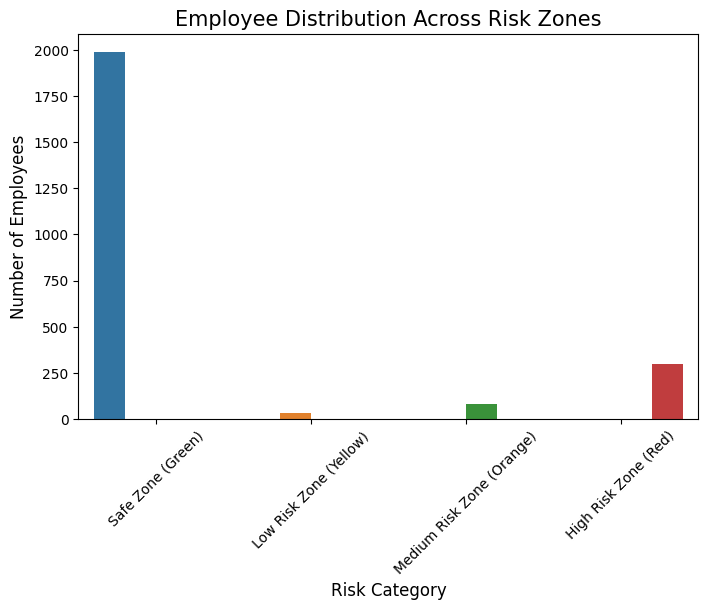

In [315]:
result_df.risk_zone.value_counts()

plt.figure(figsize=(8,5))
ax = sns.countplot(x='risk_zone', data=result_df, hue='risk_zone', legend=False)

plt.title('Employee Distribution Across Risk Zones', fontsize=15)
plt.xlabel('Risk Category', fontsize=12)
plt.xticks(rotation=45)
plt.ylabel('Number of Employees', fontsize=12)
plt.show()

### 7.2. Based on the below probability score range, categorize the employees into four zones and suggest your thoughts on the retention strategies for each zone.

#### - Safe Zone (Green) (Score < 20%) - (1986 employees)
    - appriciate those on their work, 
    - included in company's social events and team-building.
#### - Low Risk Zone (Yellow) (20% < Score < 60%)
    - use quaterly feedback on work life balance, office environment etc
    - providing training or work shop to keep them engage, 
    - assigned as mentors to the new hiried employees, this increases their sense of responsibility and belonging.
####  - Medium Risk Zone (Orange) (60% < Score < 90%)
    - public recognition or performance-based rewards to increase the employee's "Satisfaction Level".
    - provide a clear 6-month roadmap toward a promotion or new skill certification.
    - Offer remote work options or flexible hours to improve work-life balance for those showing signs of fatigue.
#### - High Risk Zone (Red) (Score > 90%).
    - immediate schedule meeting to understand employee frustation, 
    - high-value retention bonus tied to a 12-month commitment
    - immediately reducing their project load or assign them to a different, high-impact team.


